In [2]:
#General imports
resol = 300
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
pi = np.pi
from pathlib import Path
import gc
import pandas as pd

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports

from src.xp_config import ExperimentConfig
from src.experiment import Experiment
from src.rg_integrator import rg_propagator

Let me first try to find out reasonable values to reach monochr.

In [7]:
omega_A = 10*pi
Gamma = 10*pi

lbda = 10*pi
cutoffs = {'ir_cutoff': omega_A - lbda, 'uv_cutoff': omega_A + lbda}

L = 100

param_cavity = {'omega_0': omega_A, 'gamma': Gamma / (1 + Gamma / (pi*lbda)), 'L': L}

param_time_evol = {'T': L/2, 'dt': 0.05}

#photons at resonance with the atom
param_photons = {'omega_p': [omega_A, omega_A], 
                 'delta_k': [0.05*pi, 0.05*pi],
                 'x_0': [-L/4, -L/4]}

Several experiments with different spread of the wavepacket

In [8]:
sigma_tab = np.linspace(1/L * pi, pi, 2)

coincidences = np.zeros(len(sigma_tab))

for i, dk in enumerate(sigma_tab):
    print("Treating experiment : ", i)
    param_photons['delta_k'] = [dk, dk]
    xp_config = ExperimentConfig(param_cavity=param_cavity,
                                 param_time_evol=param_time_evol,
                                 param_photons=param_photons,
                                 cutoffs=cutoffs,
                                 store_state=False)

    scattering_experiment = Experiment(xp_config)
    #Propagate the state
    c_array, b1_array, b2_array = scattering_experiment.propagate_state(progress=True)
    #Compute observables
    An_array, P11n_array, P12n_array, P21n_array, P22n_array = scattering_experiment.compute_observables(progress=True)
    #Check eventual messages
    messages = scattering_experiment.get_messages()
    #Compute the coincidence probability
    C = P12n_array[-1] + P21n_array[-1]
    del scattering_experiment
    del c_array, b1_array, b2_array
    
    gc.collect()

Treating experiment :  0


100%|██████████| 999/999 [03:12<00:00,  5.18it/s]


Current messsages:
- probability_conservation
Error: Probability not conserved at final time: P11 + P12 + P21 + P22 + A =             1.003712 != 1.
Treating experiment :  1


 19%|█▉        | 193/999 [00:36<02:34,  5.23it/s]


KeyboardInterrupt: 

In [32]:
#Save the data
df = pd.DataFrame(coincidences)
filename=f"./csv_files/coincidence_resonance.csv"
df.to_csv(filename)

Figure

In [3]:
sigma_tab = np.linspace(10*sig_k_min, sig_k_min,10)

coincidences = pd.read_csv("./csv_files/coincidence_resonance.csv").to_numpy()
coincidences = coincidences[:, 1]

Max coincidence : 0.9776136867411668
At delta_k / sig_k_min = 3.0


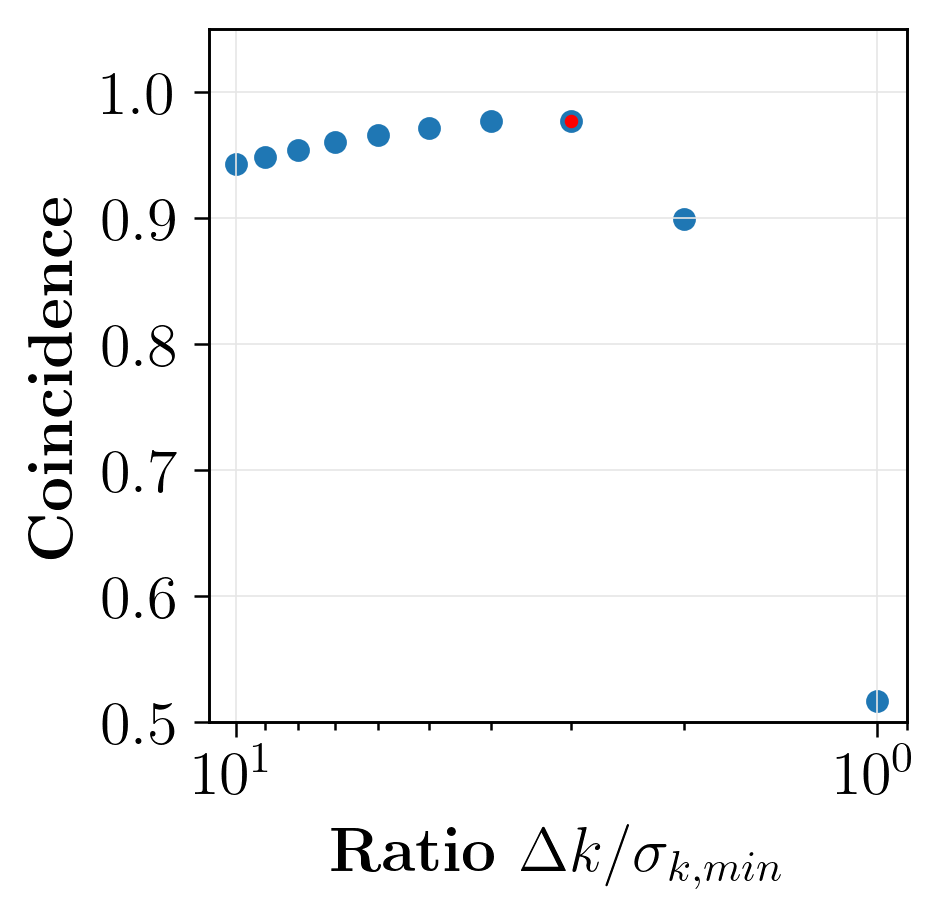

In [5]:
#print the max coincidence
print("Max coincidence :", np.max(coincidences))
#Location of the max coincidence
max_index = np.argmax(coincidences)
print("At delta_k / sig_k_min =", sigma_tab[max_index] / sig_k_min)

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)



# ---- courbes lisses ----
ax.scatter(sigma_tab / sig_k_min, coincidences, s=20)
ax.scatter(sigma_tab[max_index]/ sig_k_min, coincidences[max_index], s=5, color='red') 

# Labels, limites et grille
ax.set_xlabel(r'\textbf{Ratio} $\Delta k / \sigma_{k, min}$', fontsize=10)
ax.set_xscale('log')
ax.set_xlim([1.1*1e1, 0.9*1e0])

ax.set_ylabel(r'\textbf{Coincidence}', fontsize=10)
ax.set_ylim(0.5,1.05)

ax.grid(color='0.9', linestyle='-', linewidth=0.4)


#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(15)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

plt.show()

Max coincidence : 0.9776136867411668
At delta_k / Gamma = 0.003819718634205488


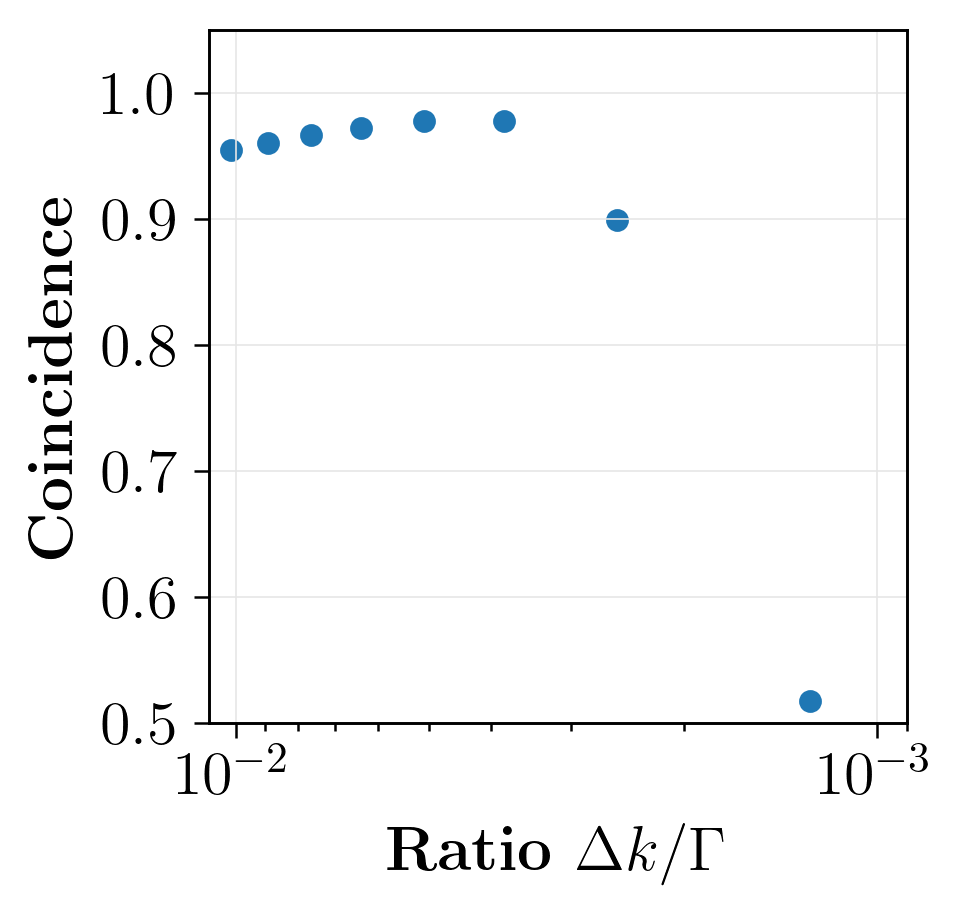

In [17]:
#print the max coincidence
print("Max coincidence :", np.max(coincidences))
#Location of the max coincidence
max_index = np.argmax(coincidences)
print("At delta_k / Gamma =", sigma_tab[max_index] / Gamma)

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)



# ---- courbes lisses ----
ax.scatter(sigma_tab / Gamma, coincidences, s=20)

# Labels, limites et grille
ax.set_xlabel(r'\textbf{Ratio} $\Delta k / \Gamma $', fontsize=10)
ax.set_xscale('log')
ax.set_xlim([1.1*1e-2, 0.9*1e-3])

ax.set_ylabel(r'\textbf{Coincidence}', fontsize=10)
ax.set_ylim(0.5,1.05)

ax.grid(color='0.9', linestyle='-', linewidth=0.4)


#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(15)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

plt.show()